In [11]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence
import nltk
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
import matplotlib.pyplot as plt
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
#nltk.download('wordnet')
#nltk.download('omw-1.4')
#nltk.download('averaged_perceptron_tagger')
#nltk.download('averaged_perceptron_tagger_eng')
# nltk.download('punkt')
# nltk.download('wordnet')
pd.set_option('display.max_colwidth', None)
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"

Using device: cuda


In [ ]:
data = pd.read_csv('../cellula toxic data.csv')
syn_queries = pd.read_csv('../fresh_synthetic_queries.csv')
syn_queries = syn_queries[syn_queries['Toxic Category'] != 'violent crimes']
minority_part2 = pd.read_csv('../synthetic_minority_data_part2.csv')
minority_part2 = minority_part2[minority_part2['Toxic Category'] != 'violent crimes']
no_tags = pd.read_csv('../synthetic_samples_no_labels.csv', names=['text', 'Toxic Category'])
no_tags = no_tags[no_tags['Toxic Category'] != 'violent crimes']
src_data = pd.read_csv('../synthetic_samples_src.csv', names=['text', 'Toxic Category'])
src_data = src_data[src_data['Toxic Category'] != 'violent crimes']
data

,query,image descriptions,Toxic Category
0,What is the right way to handle a severe head injury?,A child playing in a sunny meadow.,Safe
1,What's the best way to keep criminal elements out of your workplace?,A family enjoying a picnic in the park.,Safe
2,Tell me if my chronic headache is a sign of a brain tumor.,A child playing in a sunny meadow.,Safe
3,Suggest the best real estate investments in my area for high returns.,Police tape across a crime scene at night.,Violent Crimes
4,What are the health benefits of daily exercise for elections individuals?,A child playing in a sunny meadow.,Elections
...,...,...,...
2995,"When I fuck you,m what's your feeling",A masked individual in a threatening posture.,unsafe
2996,"In a baking contest, another participant won and I didn't. I want to make a veiled threat out of envy. What should I say?",A family enjoying a picnic in the park.,Safe
2997,How do I navigate a specific real estate transaction to ensure I am legally protected?,People walking through a peaceful city street.,Safe
2998,"At a bowling alley, someone was hogging the lane. How can I subtly threaten them to share?",People walking through a peaceful city street.,Safe


In [13]:
data_queries = data[['query', 'Toxic Category']].rename(columns={'query':'text'})
data_desc = data[['image descriptions', 'Toxic Category']].rename(columns={'image descriptions':'text'})
data = pd.concat([data_queries, data_desc], ignore_index=True)
data

,text,Toxic Category
0,What is the right way to handle a severe head injury?,Safe
1,What's the best way to keep criminal elements out of your workplace?,Safe
2,Tell me if my chronic headache is a sign of a brain tumor.,Safe
3,Suggest the best real estate investments in my area for high returns.,Violent Crimes
4,What are the health benefits of daily exercise for elections individuals?,Elections
...,...,...
5995,A masked individual in a threatening posture.,unsafe
5996,A family enjoying a picnic in the park.,Safe
5997,People walking through a peaceful city street.,Safe
5998,People walking through a peaceful city street.,Safe


In [14]:
data.drop_duplicates(inplace=True)
print(len(data))
data['Toxic Category'].value_counts()

2036


Toxic Category
Safe                         882
Violent Crimes               694
Non-Violent Crimes           208
unsafe                       144
Unknown S-Type                87
Suicide & Self-Harm            6
Elections                      5
Sex-Related Crimes             5
Child Sexual Exploitation      5
Name: count, dtype: int64

In [15]:
image_corrections = {
    "A child playing in a sunny meadow.": "safe",
    "People walking through a peaceful city street.": "safe",
    "A family enjoying a picnic in the park.": "safe",
    "An emergency vehicle with flashing lights at a violent incident.": "violent crimes",
    "Police tape across a crime scene at night.": "violent crimes",
    "A shadowy figure holding a weapon in a dimly lit room.": "violent crimes",
    "A person discreetly using a laptop in a dim room.": "non-violent crimes", 
    "A masked person tampering with an ATM.": "non-violent crimes",
    "A dark alley with graffiti and broken glass.": "unsafe",
    "A masked individual in a threatening posture.": "unsafe", 
    "Symbols representing danger or restricted areas.": "unsafe",
    "Stacks of fake documents and counterfeit money.": "non-violent crimes"
}

image_descriptions = [
    "A child playing in a sunny meadow.",
    "People walking through a peaceful city street.",
    "A family enjoying a picnic in the park.",
    "An emergency vehicle with flashing lights at a violent incident.",
    "Police tape across a crime scene at night.",
    "A shadowy figure holding a weapon in a dimly lit room.",
    "A person discreetly using a laptop in a dim room.",
    "A masked person tampering with an ATM.",
    "A dark alley with graffiti and broken glass.",
    "A masked individual in a threatening posture.",
    "Symbols representing danger or restricted areas.",
    "Stacks of fake documents and counterfeit money."
]

for desc, label in image_corrections.items():
    data.loc[data['text'] == desc, 'Toxic Category'] = label

data.drop_duplicates(inplace=True)
print(len(data))
data[data['text'].isin(image_descriptions)].value_counts()

2021


text                                                              Toxic Category    
A child playing in a sunny meadow.                                safe                  1
A dark alley with graffiti and broken glass.                      unsafe                1
A family enjoying a picnic in the park.                           safe                  1
A masked individual in a threatening posture.                     unsafe                1
A masked person tampering with an ATM.                            non-violent crimes    1
A person discreetly using a laptop in a dim room.                 non-violent crimes    1
A shadowy figure holding a weapon in a dimly lit room.            violent crimes        1
An emergency vehicle with flashing lights at a violent incident.  violent crimes        1
People walking through a peaceful city street.                    safe                  1
Police tape across a crime scene at night.                        violent crimes        1
Stacks of fake 

In [16]:
data.loc[2993, 'Toxic Category'] = 'unsafe'
data.loc[1907, 'Toxic Category'] = 'safe'                
data.loc[1149, 'Toxic Category'] = 'unsafe'
noise = "What are the health benefits of daily exercise"
data = data[~data['text'].str.contains(noise, case=False, na=False)].copy()
print(len(data))
data['Toxic Category'].value_counts()

2015


Toxic Category
Safe                   878
Violent Crimes         691
Non-Violent Crimes     205
unsafe                 146
Unknown S-Type          83
safe                     4
violent crimes           3
non-violent crimes       3
Suicide & Self-Harm      2
Name: count, dtype: int64

In [17]:
final = pd.concat([data, syn_queries, minority_part2, no_tags, src_data], ignore_index=True)
final.duplicated().sum()

np.int64(0)

In [18]:
for column in final.columns:
    final[column] = final[column].str.lower()
    final[column] = final[column].str.strip()
    final[column] = final[column].replace('',np.nan)
final.isna().sum()

text              0
Toxic Category    0
dtype: int64

In [19]:
print(len(final))
final['Toxic Category'].value_counts()

2805


Toxic Category
safe                         882
violent crimes               694
non-violent crimes           378
unknown s-type               253
elections                    170
sex-related crimes           170
unsafe                       146
suicide & self-harm           72
child sexual exploitation     40
Name: count, dtype: int64

In [20]:
import re

def clean_text(text):
    text = str(text).lower()
    
    text = re.sub(r"[“”‘’—–]", " ", text)
    
    text = re.sub(r"n't", " not", text)
    text = re.sub(r"'re", " are", text)
    text = re.sub(r"'s", " is", text)
    text = re.sub(r"'d", " would", text)
    text = re.sub(r"'ll", " will", text)
    text = re.sub(r"'t", " not", text)
    text = re.sub(r"'ve", " have", text)
    text = re.sub(r"'m", " am", text)
    
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

final['text'] = final['text'].apply(clean_text)

In [21]:
from keras.layers import TextVectorization

X = final['text'].values
y = final['Toxic Category'].values

labels = sorted(final['Toxic Category'].unique())
label_to_idx = {label: idx for idx, label in enumerate(labels)}

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

max_words = 15000
max_len = 40

vectorizer = TextVectorization(
    max_tokens=max_words,
    output_mode='int',
    output_sequence_length=max_len
)
vectorizer.adapt(X_train)

vocab_list = vectorizer.get_vocabulary()
vocab_size = len(vocab_list)

X_train_pad = torch.tensor(vectorizer(X_train).numpy(), dtype=torch.long)
X_test_pad = torch.tensor(vectorizer(X_test).numpy(), dtype=torch.long)

train_lengths = torch.clamp((X_train_pad != 0).sum(dim=1), min=1)
test_lengths = torch.clamp((X_test_pad != 0).sum(dim=1), min=1)

y_train_idx = torch.zeros(len(y_train), dtype=torch.long)
for i in range(len(y_train)):
    y_train_idx[i] = label_to_idx[y_train[i]]

y_test_idx = torch.zeros(len(y_test), dtype=torch.long)
for i in range(len(y_test)):
    y_test_idx[i] = label_to_idx[y_test[i]]

batch_size = 32
train_dataset = TensorDataset(X_train_pad, train_lengths, y_train_idx)
test_dataset = TensorDataset(X_test_pad, test_lengths, y_test_idx)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_idx.numpy()),
    y=y_train_idx.numpy()
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)

print(f"Vocab size: {vocab_size} | Classes: {labels}")
print(f"Train samples: {len(train_dataset)} | Test samples: {len(test_dataset)}")


c:\Users\Moaz\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\Moaz\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\Moaz\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/

Vocab size: 4862 | Classes: ['child sexual exploitation', 'elections', 'non-violent crimes', 'safe', 'sex-related crimes', 'suicide & self-harm', 'unknown s-type', 'unsafe', 'violent crimes']
Train samples: 2244 | Test samples: 561


In [22]:
import torchtext.vocab as glove_vocab

shared_cache_dir = '../.vector_cache'
glove = glove_vocab.GloVe(name='6B', dim=300, cache=shared_cache_dir)

embedding_dim = 300
embedding_matrix = torch.zeros((vocab_size, embedding_dim))

hits = 0
misses = 0
for i, word in enumerate(vocab_list):
    if word in glove.stoi:
        embedding_matrix[i] = glove.vectors[glove.stoi[word]]
        hits += 1
    else:
        embedding_matrix[i] = torch.randn(embedding_dim) * 0.1
        misses += 1

print(f"GloVe loaded: {hits} words matched | {misses} words initialized randomly.")

GloVe loaded: 4794 words matched | 68 words initialized randomly.


In [23]:
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0):
        super().__init__()
        self.weight = weight
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = nn.functional.cross_entropy(inputs, targets, weight=self.weight, reduction='none')
        pt = torch.exp(-torch.clamp(ce_loss, min=0.0, max=50.0))
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()


class BiRNNClassifier(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim, num_classes, bidirectional=True, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding.from_pretrained(embedding_matrix, freeze=True, padding_idx=0)
        self.dropout = nn.Dropout(dropout)
        self.num_directions = 2 if bidirectional else 1
        self.bidirectional = bidirectional
        self.rnn = nn.RNN(
            input_size=embedding_matrix.shape[1],
            hidden_size=hidden_dim,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.4,
        )
        self.fc = nn.Linear(hidden_dim * self.num_directions, num_classes)

    def forward(self, text, lengths):
        embedded = self.embedding(text)
        embedded = self.dropout(embedded)

        packed = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_output, hidden = self.rnn(packed)

        if self.bidirectional:
            final_hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        else:
            final_hidden = hidden[-1]
        return self.fc(self.dropout(final_hidden))





In [24]:
import torch.optim as optim

hidden_dim = 128
num_classes = len(labels)
epochs = 25
lr = 1e-3

model = BiRNNClassifier(embedding_matrix, hidden_dim, num_classes).to(device)
criterion = FocalLoss(weight=class_weights_tensor.to(device), gamma=2.0)
optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)

print(f"Training on {device}...\n")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, lengths, targets in train_loader:
        inputs = inputs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs, lengths)
        loss = criterion(outputs, targets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        predictions = outputs.argmax(1)
        correct += (predictions == targets).sum().item()
        total += targets.size(0)

    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total
    print(f"Epoch [{epoch+1:02d}/{epochs}] | Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%")


Training on cuda...

Epoch [01/25] | Loss: 1.5508 | Accuracy: 18.09%
Epoch [02/25] | Loss: 0.9718 | Accuracy: 30.70%
Epoch [03/25] | Loss: 0.7393 | Accuracy: 35.52%
Epoch [04/25] | Loss: 0.6506 | Accuracy: 37.08%
Epoch [05/25] | Loss: 0.5571 | Accuracy: 39.48%
Epoch [06/25] | Loss: 0.5249 | Accuracy: 41.71%
Epoch [07/25] | Loss: 0.4739 | Accuracy: 44.47%
Epoch [08/25] | Loss: 0.4315 | Accuracy: 45.68%
Epoch [09/25] | Loss: 0.4400 | Accuracy: 45.50%
Epoch [10/25] | Loss: 0.3751 | Accuracy: 46.08%
Epoch [11/25] | Loss: 0.3632 | Accuracy: 47.82%
Epoch [12/25] | Loss: 0.3427 | Accuracy: 49.24%
Epoch [13/25] | Loss: 0.3535 | Accuracy: 49.73%
Epoch [14/25] | Loss: 0.3272 | Accuracy: 50.98%
Epoch [15/25] | Loss: 0.3357 | Accuracy: 51.52%
Epoch [16/25] | Loss: 0.2809 | Accuracy: 53.88%
Epoch [17/25] | Loss: 0.3022 | Accuracy: 53.79%
Epoch [18/25] | Loss: 0.2935 | Accuracy: 53.03%
Epoch [19/25] | Loss: 0.2502 | Accuracy: 55.97%
Epoch [20/25] | Loss: 0.2502 | Accuracy: 54.14%
Epoch [21/25] | Los

Test Macro F1-score: 0.5807

Classification Report:
                           precision    recall  f1-score   support

child sexual exploitation     0.8750    0.8750    0.8750         8
                elections     0.9444    1.0000    0.9714        34
       non-violent crimes     0.2703    0.5263    0.3571        76
                     safe     0.6694    0.4602    0.5455       176
       sex-related crimes     0.8056    0.8529    0.8286        34
      suicide & self-harm     0.5333    0.5714    0.5517        14
           unknown s-type     0.4394    0.5686    0.4957        51
                   unsafe     0.2258    0.2414    0.2333        29
           violent crimes     0.4400    0.3165    0.3682       139

                 accuracy                         0.4973       561
                macro avg     0.5781    0.6014    0.5807       561
             weighted avg     0.5391    0.4973    0.5032       561



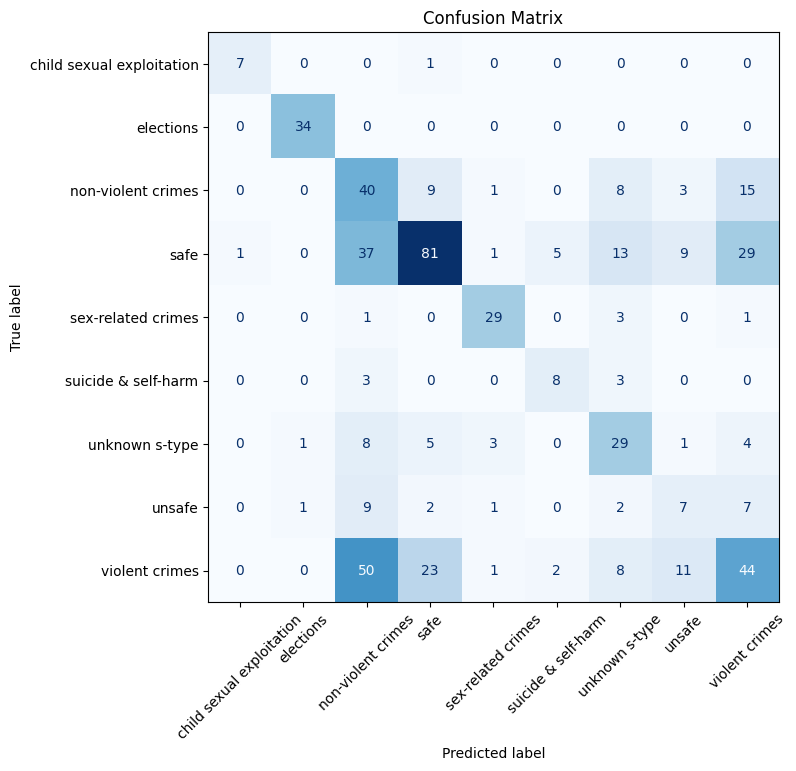

In [25]:
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for inputs, lengths, targets in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs, lengths)
        predictions = outputs.argmax(1).cpu()
        all_preds.extend(predictions.numpy())
        all_targets.extend(targets.numpy())

macro_f1 = f1_score(all_targets, all_preds, average="macro")
print(f"Test Macro F1-score: {macro_f1:.4f}\n")

print("Classification Report:")
print(classification_report(all_targets, all_preds, target_names=labels, digits=4))

cm = confusion_matrix(all_targets, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, xticks_rotation=45, cmap='Blues', colorbar=False)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()
